In [159]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.stats import chi2
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.special import hyp2f1
from scipy.integrate import quad
from matplotlib.lines import Line2D

# Fig 1: Conceptual Figure 

Here we have visualize how simple functional forms of $\theta(N_0)$ affects the probability of rescue $P_\text{res} = 1 - \exp(-\theta(N_0)N_0)$

We depict three different functions 
1. $\theta(N_0) = \theta_1$, i.e., it is independent of $N_0$ (black line) 
2. $\theta(N_0) = \displaystyle \frac{\theta_1}{1+\theta_2 N_0}$, a decreasing function of $N_0$ (blue line). This starts at the same place as the black line but saturates at a much lower value. 
3. $\theta(N_0) = \displaystyle \frac{a_1 N_0}{1+a_2 N_0}$, is an increasing function of $N_0$ (red line). The values chosen are such that it start below the black line but increases to a value higher than the black line.

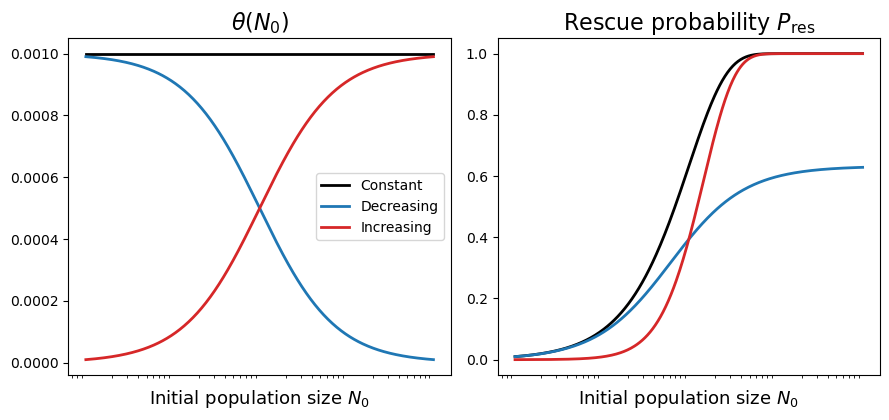

In [237]:
# --- Data ---
N_rng = np.logspace(1, 5, 400)

theta = 1e-3
theta_2 = 1e-3
a1 = 1e-6
a2 = 1e-3

theta_std = theta * np.ones_like(N_rng)
theta_positive = theta / (1 + theta_2 * N_rng)
theta_negative =   a1*N_rng / (1 + a2 * N_rng) #1.5 * theta / (1 + a1 * np.exp(-a2 * N_rng))

theta_sets = {
    "Constant": theta_std,
    "Decreasing": theta_positive,
    "Increasing": theta_negative,
}

# --- Figure setup ---
plt.style.use("default")
fig, ax = plt.subplots(1, 2, figsize=(9, 4.3), sharex=True)

colors = ["black", "#1f77b4", "#d62728"]

# --- Plotting ---
for (label, theta_rng), c in zip(theta_sets.items(), colors):
    P_res = 1 - np.exp(-theta_rng * N_rng)

    ax[0].plot(N_rng, theta_rng, label=label, lw=2, color=c)
    ax[1].plot(N_rng, P_res, lw=2, color=c)

# --- Axes formatting ---
for a in ax:
    a.set_xscale("log")
    a.grid(False)

    # Keep full box frame
    for spine in a.spines.values():
        spine.set_visible(True)

    # Remove all ticks and tick labels
    a.set_xticks([])
#ax[0].set_yticks([])
    
ax[0].set_title(r"$\theta(N_0)$", fontsize=16)
ax[1].set_title("Rescue probability " + r"$P_\text{res}$" , fontsize=16)

#ax[0].set_ylabel(r"$\theta(N_0)$", fontsize=12)
#ax[1].set_ylabel(r"$P_{\mathrm{rescue}}$", fontsize=12)

for a in ax:
    a.set_xlabel(r"Initial population size $N_0$", fontsize=13)
    a.tick_params(axis='both', labelsize=10)

ax[0].legend(frameon=True)
#ax[0].axhline(y=0, linestyle='--')
plt.tight_layout()
plt.savefig("ConceptualFigure.png")
plt.show()

# Analytical value of rescue probability 

This is the code for the exact resuce probability computed from theory. I use it to then simulate rescue probability over a finite number of replicates. I am doing this until we have finalized the parameters to run the full simulations for.

In [76]:
def hyp2f1_pq(p,q,x):
    return hyp2f1(q,p,1+p,x)

def pest(x,bw,dw,bm,dm,R,gw,gm,N0): 
    rw = bw-dw 
    rm = bm-dm 
    Jt = (bm+dm)/rm * hyp2f1_pq(-rm/rw, -bm/bw, x) - bm/bw * x/(1-rm/rw) * hyp2f1_pq(1-rm/rw, 1-bm/bw,x) 
    Jt = Jt/  ( 1 -x )**(bm/bw)
    return 2*(1+Jt)**(-1)

def Pres(bw,dw,bm,dm,R,gw,gm,N0,mu) : 
    rw = bw-dw
    def integrand_alt(x): 
        return mu*R*pest(x,bw,dw,bm,dm,R,gw,gm,N0)/(gw*(1-x))    
    
    if R == np.inf: 
        Pres_density = 1-np.exp(mu*N0*(bm-dm)/(bm*(bw-dw)))
    else: 
        n0 = N0/R 
        Pres_density = 1- np.exp( - quad(integrand_alt, 0, n0/(n0-rw/gw))[0] )
    return Pres_density 

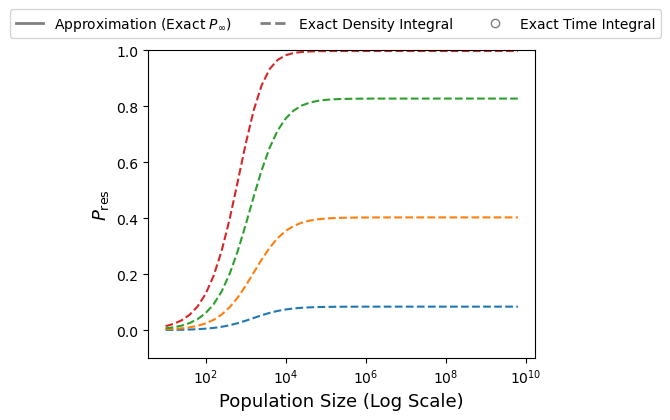

In [93]:
fig, ax = plt.subplots(1,1,figsize = (5,4))
N0_rng = [ round(10**x) for x in np.arange(1,10,0.2) ] 
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]
R = 10**4
for sm_ind, sm in enumerate([0.01,0.05,0.15, 0.5]) : 
    bw = 0.35 + np.log(0.95)/2
    bm = 0.35 + np.log(1 + sm)/2
    dw = 0.35 - np.log(0.95)/2
    dm = 0.35 - np.log(1+ sm)/2
    mu = 10**(-4)
    rw = bw-dw
    rm = bm-dm
    gw = bw 
    gm = bm
    
    Pres_rng = [Pres(bw,dw,bm,dm,R,gw,gm,N0,mu) for N0 in N0_rng]
    Pres_rng = np.array(Pres_rng) 
    Pres_rng = np.transpose(Pres_rng)

    #ax.scatter(N0_rng, Pres_rng[0], facecolors='none', edgecolor = colors[sm_ind], s=5, label = str(sm)) #, label = 'Time Integral'
    ax.plot(N0_rng, Pres_rng, linestyle = '--', color = colors[sm_ind]) #, label = 'Density Integral'

    #plt.plot(N0_rng, [Pres_theory(bw,dw,bm,dm,K,N0,mu) for N0 in N0_rng], label = 'Approximation 1')
    #plt.plot(N0_rng, [Pres_theory2(bw,dw,bm,dm,K,N0,mu) for N0 in N0_rng], label = 'Approximation 2')


#fig, ax = plt.subplots()

# ---- your existing plot code ----
# ax.plot(x, y)

# ---- custom legend handles ----
legend_elements = [
    Line2D([0], [0], color='gray', lw=2, linestyle='-',
           label=r'Approximation (Exact $P_\infty$)'),
    Line2D([0], [0], color='gray', lw=2, linestyle='--',
           label='Exact Density Integral'),
    Line2D([0], [0], marker='o', color='gray',
           markerfacecolor='none', linestyle='None',
           label='Exact Time Integral')
]

fig.legend(handles=legend_elements, loc = 'upper center', ncol=len(legend_elements), bbox_to_anchor=(0.5, 1))

#plt.show()
#ax.legend(title ='Mutant growth rate', loc = 'upper right')
ax.set_xlabel("Population Size (Log Scale)", fontsize = 13)
ax.set_ylabel(r"$P_\text{res}$", fontsize = 13)
ax.set_xscale('log')
ax.set_ylim(-0.1, 1.0)
plt.savefig("PR_neg_denisty_Approximation.png", format='png', bbox_inches="tight")
#plt.tight_layout()

# Figure 2: Bacterial 

Here I fit two models to simulated data intended to match bacterial simulations. The exact parameters still need to be finalized but here I describe the statistical methods and potential plots. 

The two models I am fitting are (i) the null model $P_\text{res} = 1-\exp(-\theta N_0)$ and (ii) the alternative model $P_\text{res} = 1-\exp(-\displaystyle \frac{\theta_1}{1 + \theta_2 N_0} N_0)$. Note that this is a case of a nested model, so we are testing for if $\theta_2$ is significantly different from $0$ to reject the null model. 

To do this we fit the data to a generalized linear model (GLM) with a specific link functions. More simply, our data is a list of initial population sizes $N_{0,i}$ , the observed number of succesful rescue $y_i$ over a specified number of replicates $N_R$. Then the likelihood of observing the data given specific values of $\theta$s is 

$$ \displaystyle \sum_{i} {N_R \choose y_i} P_\text{res}^{y_i} (1-P_\text{res})^{N_R-y_i} $$ 

Now the $P_\text{res}$ here depends on $N_{0,i}$ and the $\theta$s.. 

We choose $\theta$ for the null model that minimizes the negative log-likelihood (-$L_\text{null}$) and $(\theta_1, \theta_2)$ that minimizes the negative log-likelihood (-$L_\text{alt}$) for the alternative model. Then we decide whether to reject the null model by looking at the deviance $D = L_\text{alt} - L_\text{null}$. 

$D$ is supposed to be distributed according to a $\chi^2$ distribution with one degree of freedom. Then we can compute the probability $P(D < \chi^2)$.

In [198]:
def model1(x, theta):
    return 1 - np.exp(-theta[0] * x)
def model2(x, theta):
    return 1 - np.exp(-theta[0] * x/(1+theta[1]*x) )


def neg_log_lik(model, theta, x, y, N):
    p = model(x,theta) 
    p = np.clip(p, 1e-12, 1-1e-12)
    
    ll = y * np.log(p) + (N - y) * np.log(1 - p)
    return -np.sum(ll)


def MLE_fit(Ndata_range, PRdata_range, model, theta0, bounds, NoR): 
    x = np.array(Ndata_range)
    N = np.array([NoR for xi in x])
    y = np.array([PR*NoR for PR in PRdata_range])

    res = minimize(
        lambda t: neg_log_lik(model, t, x, y, N),
        x0=theta0,
        bounds=bounds
    )

    theta = res.x
    
    PRpred_range = np.array([model(N, theta) for N in Ndata_range])
    
    ss_res = np.sum((PRdata_range - PRpred_range)**2)
    ss_tot = np.sum((PRdata_range - np.mean(PRdata_range))**2)
    r2 = 1 - ss_res/ss_tot
    
    
    return theta, r2, neg_log_lik(model, theta, x, y, N)



1930


/tmp/ipykernel_94375/2214092420.py:2: RuntimeWarning: overflow encountered in exp
  return 1 - np.exp(-theta[0] * x)
/tmp/ipykernel_94375/2214092420.py:30: RuntimeWarning: overflow encountered in square
  ss_res = np.sum((PRdata_range - PRpred_range)**2)
/tmp/ipykernel_94375/2214092420.py:4: RuntimeWarning: overflow encountered in exp
  return 1 - np.exp(-theta[0] * x/(1+theta[1]*x) )


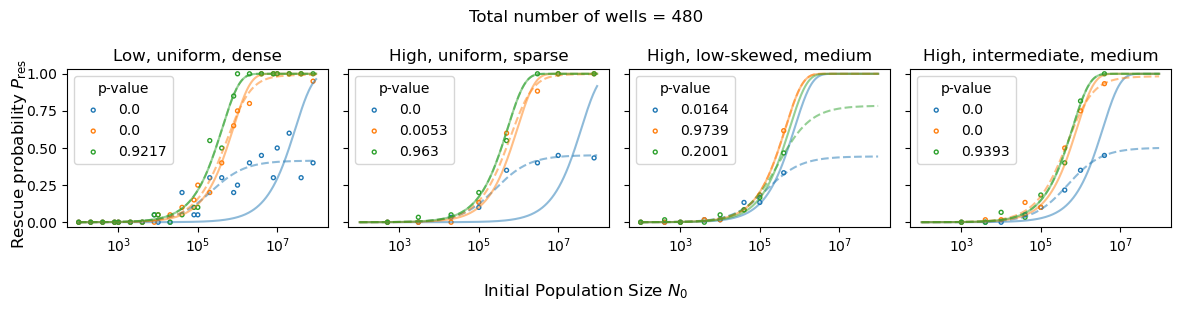

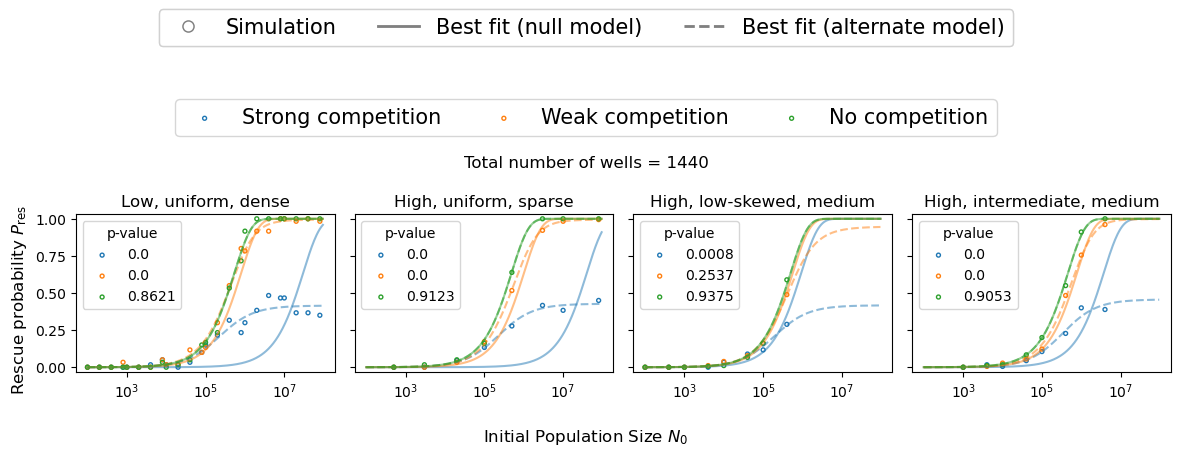

In [260]:
N0range_vals = [[1e2,2e2,4e2,8e2,1e3,2e3,4e3,8e3,1e4,2e4,4e4,8e4,1e5,2e5,4e5,8e5,1e6,2e6,4e6,8e6,1e7,2e7,4e7,8e7],
                  [5e2,3e3,2e4,1e5,5e5,3e6,1e7,8e7], [1e2,4e2,1e3,4e3,1e4,4e4,1e5,4e5], [1e3,4e3,1e4,4e4,1e5,4e5,1e6,4e6] ] #  [1e2,4e2,1e3,4e3,1e4,4e4,1e5,4e5,1e6,4e6,1e7,4e7]
scheme_names = [ "Low, uniform, dense", "High, uniform, sparse", "High, low-skewed, medium", "High, intermediate, medium" ]
R_names = ["Strong competition", "Weak competition", "No competition"]

bw = 0.5 - 0.01 #np.log(0.95)/2
bm = 0.5 + 0.01 #np.log(1 + sm)/2
dw = 0.5 + 0.01 #np.log(0.95)/2
dm = 0.5 - 0.01 #np.log(1+ sm)/2
mu = 10**(-6)
gw = 0.01
gm = 0.01

seed = int(np.random.random()*10**4)
np.random.seed(seed)
print(seed)
for total_well in [480, 1440]: 
    fig, ax = plt.subplots(1,len(sampling_schemes),figsize=(len(sampling_schemes)*3,3), sharex=True, sharey= True)
    for ind, N0range in enumerate(N0range_vals): 
        for ind_R, R in enumerate([10**5, 10**6, np.inf]): 
            NoR = round(total_well/len(N0range)) #Number of replicates
            PRdata = [np.random.binomial(NoR,Pres(bw,dw,bm,dm,R,gw,gm,N0,mu))/NoR for N0 in N0range ]

            r2_1old = 0
            theta0 = [0.001]
            bounds = [(-1e9,None)]
            best_theta, best_nll1, best_r2_1 = None, np.inf, 0
            for t0_init in [10**k for k in range(-9,-1,2)]:
                theta0[0] = t0_init
                theta, r2_1, nll1 = MLE_fit(N0range, PRdata, model1, theta0, bounds, NoR)
                if nll1 < best_nll1:
                    best_nll1 = nll1
                    best_theta = theta
                    best_r2_1 = r2_1
            theta1, r2_1, nll1 = best_theta, best_r2_1, best_nll1
            #theta, r2_1, nll1 = MLE_fit(N0range, PRdata, model1, theta0, bounds, NoR)
            N_range = [ 10**x for x in np.arange(2,8,0.02) ] 
            PR_range = [model1(N, theta1) for N in N_range]
            ax[ind].plot(N_range, PR_range, color="C"+str(ind_R), alpha=0.5)

            r2_2old = 0
            theta0 = [0.001, 0]
            bounds = [(-1e9,None),(-1e-9,None)]
            best_theta, best_nll2, best_r2_2 = None, np.inf, 0
            for t0_init in [10**k for k in range(-9,-1,2)]:
                theta0[0] = t0_init
                for t1_init in np.arange(0, 1.01, 0.2):
                    theta0[1] = t1_init
                    theta, r2_2, nll2 = MLE_fit(N0range, PRdata, model2, theta0, bounds, NoR)
                    if nll2 < best_nll2:
                        best_nll2 = nll2
                        best_theta = theta
                        best_r2_2 = r2_2
            theta1, r2_2, nll2 = best_theta, best_r2_2, best_nll2

            N_range = [ 10**x for x in np.arange(2,8,0.02) ] 
            PR_range = [model2(N, theta1) for N in N_range]
            ax[ind].plot(N_range, PR_range, color="C"+str(ind_R), linestyle = '--', alpha=0.5)

            LR = 2 * (-nll2 + nll1)
            p_value = chi2.sf(LR, df=1)
            ax[ind].scatter(N0range, PRdata, facecolors = 'none', edgecolors = "C"+str(ind_R), s=8, label=str(round(p_value,4)))

            #print(scheme_names[ind],theta, LR, LR-2)

        ax[ind].set_xscale("log")
        ax[ind].set_title(scheme_names[ind])
        ax[ind].set_ylim((-0.03,1.03))
        ax[ind].legend(loc='upper left', title="p-value")

    fig.supxlabel(r"Initial Population Size $N_0$")
    fig.supylabel(r"Rescue probability $P_\text{res}$")
    fig.suptitle(r"Total number of wells = " + str(total_well))
    fig.tight_layout()

handles, _ = ax[0].get_legend_handles_labels()
new_labels = ["Strong competition", "Weak competition", "No competition"]
fig.legend(handles,
           new_labels,
           loc="upper center",
           ncol=len(new_labels),
           frameon=True,
          fontsize=15,
          bbox_to_anchor=(0.5, 1.2))
custom_handles = [
    Line2D([0], [0], marker='o', color='gray',
           markerfacecolor='none', markeredgecolor='gray', markersize=8, linestyle='None'),
    Line2D([0], [0], color='gray', linewidth=2),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--')
]

custom_labels = [
    "Simulation",
    "Best fit (null model)",
    "Best fit (alternate model)"
]

# --- second legend ---
leg2 = fig.legend(
    custom_handles,
    custom_labels,
    loc="upper center",
    ncol=3,
    frameon=True,
    fontsize=15,
    bbox_to_anchor=(0.5, 1.5)
)

# Important: keep both legends
fig.add_artist(leg2)
fig.tight_layout()


So above, I have plotted data for four sampling schemes across two total number of wells which determines the product of the number of population sizes we can experiment and the number of replicates per experiment. The four schemes were 

1. Low, uniform, dense: Low number of replicates per population size, the initial population size range is uniform across the whole range and dense. (24 populations with 20 replicates each)
2. High, uniform, sparse: High number of replicates per population size, the initial population size range is uniform across the whole range but sparser. (8 populations with 60 replicates each)
3. High, low-skewed, medium: High number of replicates per population size, the initial population size range is skewed towards lower values and number of replicates is intermediate. (8 populations with 60 replicates each)
4. High, intermediate, mediume: High number of replicates per population size, the initial population size range is centered around the increase and number of replicates is intermediate. (8 populations with 60 replicates each)

Even with 480, replicates, one can usually easily detect competition (even when it is weak) expect if the population size range is low-skewed. 